<a href="https://colab.research.google.com/github/vishalakshi-19/ML_Week1/blob/main/mlpractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harpartapsingh13/student-burnout-and-dropout-risk-dataset")

print("Path to dataset files:", path)

100%|██████████| 24.3k/24.3k [00:00<00:00, 5.09MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harpartapsingh13/student-burnout-and-dropout-risk-dataset/versions/1


In [5]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

In [6]:
df.head()

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
1,STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
2,STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
3,STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
4,STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


In [7]:
df.sample(10)

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
257,STU00258,23,Male,4,Engineering,Hostel,98.1,3.2,7.38,1.0,...,High,4.9,7.8,4.8,2.6,6.8,NaN,No,Low,No
37,STU00038,25,Female,1,Arts,Day Scholar,57.2,3.9,7.20,0.0,...,NaN,1.4,6.4,5.2,6.0,5.7,NaN,No,Medium,Yes
489,STU00490,19,Male,1,Business,PG/Rented,62.5,4.9,5.99,0.0,...,Middle,3.9,4.9,8.5,4.3,6.3,5.0,Yes,Medium,Yes
160,STU00161,18,Female,3,Arts,Day Scholar,82.0,4.9,4.93,1.0,...,Upper-Middle,1.8,9.5,9.2,NaN,7.9,4.2,No,Low,No
241,STU00242,19,Female,3,Science,Day Scholar,95.4,0.0,8.77,1.0,...,Lower-Middle,NaN,NaN,8.0,5.3,10.0,5.2,No,Low,No
258,STU00259,22,NaN,2,Engineering,Day Scholar,78.0,5.1,7.04,1.0,...,Middle,NaN,5.8,4.0,6.3,9.1,4.8,No,Medium,No
390,STU00391,21,Female,4,Arts,Hostel,64.0,1.6,6.77,0.0,...,Upper-Middle,7.2,10.0,5.9,4.8,3.2,4.7,No,Medium,Yes
564,STU00565,24,Male,4,Arts,Day Scholar,NaN,3.1,8.57,0.0,...,Lower-Middle,NaN,NaN,4.0,5.3,6.5,4.8,No,Low,No
787,STU00788,24,Female,2,Business,Hostel,64.9,3.2,5.74,1.0,...,Low,3.7,6.7,10.0,6.7,4.0,4.5,No,High,Yes
458,STU00459,23,Male,3,Arts,Hostel,89.3,8.1,7.97,1.0,...,Lower-Middle,4.1,5.5,6.3,4.8,7.0,9.0,No,Low,No


In [8]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,30
Year_of_Study,0
Department,23
Residence_Type,17
Attendance_Percent,51
Study_Hours_Per_Day,35
Previous_GPA,35
Backlogs,15


In [9]:
df['Part_Time_Job']

,Part_Time_Job
0,Yes
1,Yes
2,No
3,Yes
4,No
...,...
795,No
796,Yes
797,No
798,No


In [10]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df['Dropout_Risk']=le.fit_transform(df['Dropout_Risk'])

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [12]:
x_train,x_test,y_train,y_test= train_test_split(df.drop('Dropout_Risk',axis=1),df['Dropout_Risk'],test_size=0.2,random_state=42)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.impute import SimpleImputer

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

In [15]:
df['Part_Time_Job']

,Part_Time_Job
0,Yes
1,Yes
2,No
3,Yes
4,No
...,...
795,No
796,Yes
797,No
798,No


In [16]:
num_cols = [
'Age',
'Year_of_Study',
'Attendance_Percent'	,
'Study_Hours_Per_Day',
'Previous_GPA',
'Backlogs',
'Sleep_Hours'	,
'Screen_Time_Hours'	,
'Exercise_Freq_Per_Week'	,
'Social_Activity_Score'	,

'Financial_Stress_Score',
'Stress_Level',
'Anxiety_Score','Motivation_Score',
'Peer_Pressure_Score']
cat_cols = ['Gender','Department',
'Residence_Type','Part_Time_Job','Counseling_Access']

In [17]:
num_pipeline = Pipeline([("imputer",SimpleImputer(strategy="mean")),("scaler",StandardScaler())])
burnout_pipeline = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OrdinalEncoder(categories=[["Low","Medium","High"]]))])
Family_Income_Bracket_pipeline =Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OrdinalEncoder(categories=[["Low","Lower-Middle","Middle","Upper-Middle","High"]]))])
cat_pipeline = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(drop= "first",handle_unknown="ignore",sparse_output=False))])

In [18]:
transformer = ColumnTransformer([
    ("num",num_pipeline,num_cols),("cat",cat_pipeline,cat_cols),("burnout",burnout_pipeline,["Burnout_Level"]),("Family_Income_Bracket",Family_Income_Bracket_pipeline,["Family_Income_Bracket"])
])

In [19]:
x_train_transf= transformer.fit_transform(x_train)
x_test_transf = transformer.transform(x_test)

In [20]:
x_train_transf = pd.DataFrame(x_train_transf,columns=transformer.get_feature_names_out(),index=x_train.index)

x_test_transf = pd.DataFrame(x_test_transf,columns=transformer.get_feature_names_out(),index=x_test.index)

In [21]:
x_train_transf.isnull().sum()

,0
num__Age,0
num__Year_of_Study,0
num__Attendance_Percent,0
num__Study_Hours_Per_Day,0
num__Previous_GPA,0
num__Backlogs,0
num__Sleep_Hours,0
num__Screen_Time_Hours,0
num__Exercise_Freq_Per_Week,0
num__Social_Activity_Score,0


In [22]:
x_train_transf

,num__Age,num__Year_of_Study,num__Attendance_Percent,num__Study_Hours_Per_Day,num__Previous_GPA,num__Backlogs,num__Sleep_Hours,num__Screen_Time_Hours,num__Exercise_Freq_Per_Week,num__Social_Activity_Score,...,cat__Department_Engineering,cat__Department_Law,cat__Department_Medicine,cat__Department_Science,cat__Residence_Type_Hostel,cat__Residence_Type_PG/Rented,cat__Part_Time_Job_Yes,cat__Counseling_Access_Yes,burnout__Burnout_Level,Family_Income_Bracket__Family_Income_Bracket
264,-1.110682,1.560318,-0.988854,-2.060499e+00,-0.966310,-0.878453,0.880907,2.454084,-0.656490,-0.613787,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0
615,0.437139,1.560318,-2.057173,-1.275750e+00,0.337294,0.189336,-0.408030,-0.805954,-1.337453,-1.296146,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,3.0
329,0.437139,-0.263615,0.884363,2.904155e-16,0.330011,-0.878453,1.220101,0.451489,1.386397,-0.508808,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
342,1.211049,-0.263615,-2.305959,8.169143e-01,-0.099669,0.189336,1.898489,0.591205,0.024472,-1.138679,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0
394,-1.110682,0.648351,1.689261,3.216534e-02,-1.374142,0.189336,-0.000998,0.265202,-0.656490,1.170847,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.824094,-1.175582,1.030708,1.470872e+00,-0.347281,-0.878453,0.066841,1.662361,-1.337453,1.223336,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
106,0.824094,1.560318,0.086783,-2.948134e-01,-0.507500,-0.878453,-0.679386,-1.318246,1.386397,0.383508,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
270,-0.336772,1.560318,-0.542501,2.283526e-01,0.220770,0.189336,-1.018580,1.336357,-1.337453,-1.821038,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
435,-1.110682,-1.175582,-1.749848,-1.995103e+00,-0.318150,1.257126,1.627134,0.684349,1.386397,-0.613787,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0


In [23]:
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score


In [24]:
model =DecisionTreeClassifier(max_depth=5,random_state=42)
model.fit(x_train_transf,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

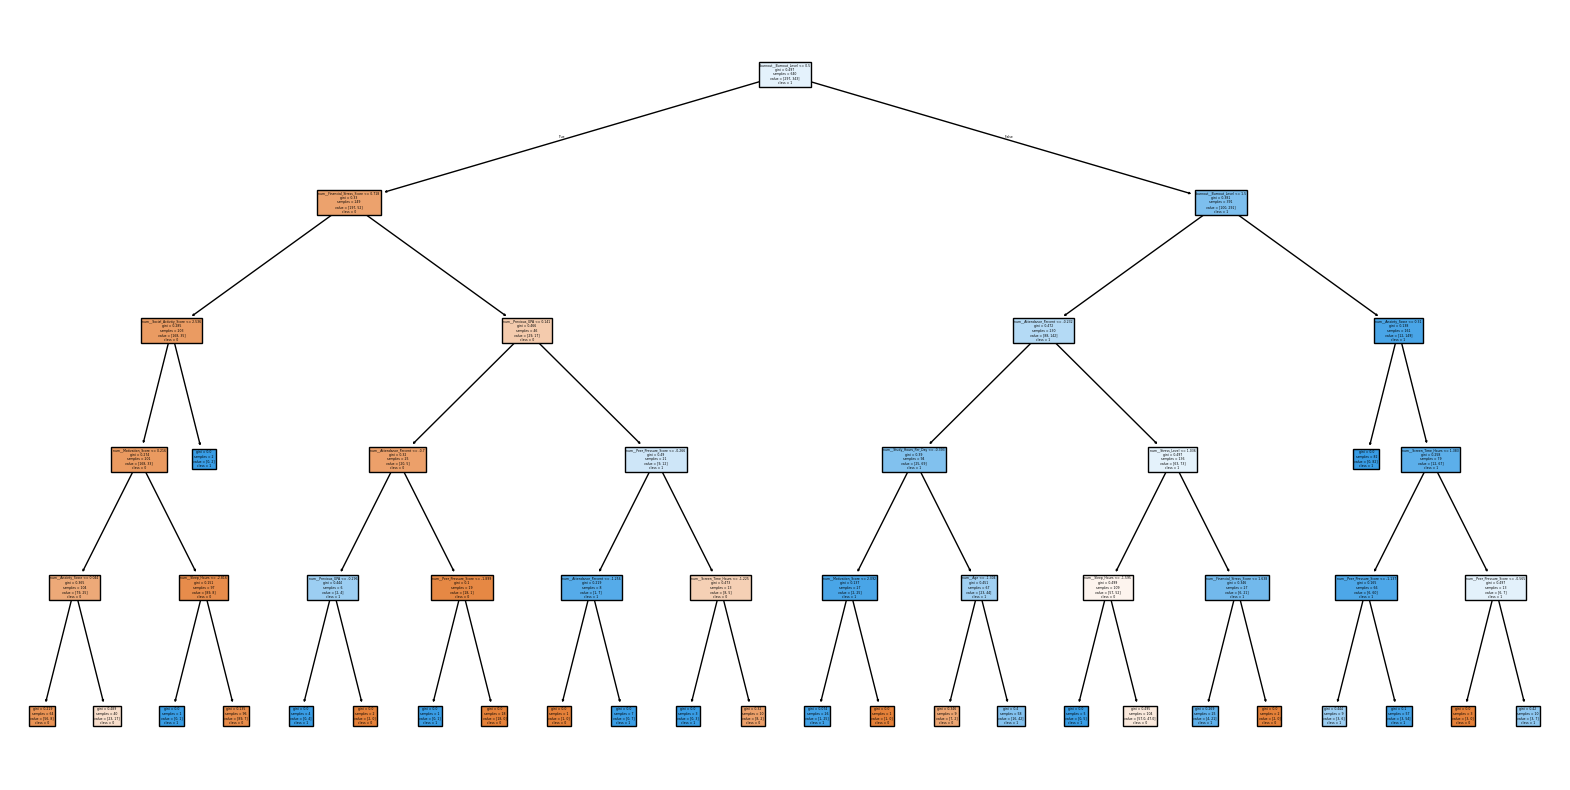

In [26]:
plt.figure(figsize=(20,10))
plot_tree(model,feature_names=transformer.get_feature_names_out(),class_names=[str(c) for c in model.classes_],filled=True)
plt.show()

In [27]:
y_pred= model.predict(x_test_transf)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.65625


In [28]:
from sklearn.linear_model import LinearRegression,Ridge
model1 = LinearRegression(fit_intercept=True)
model2 = Ridge(alpha=0.5)


In [29]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df['Dropout_Risk']=le.fit_transform(df['Dropout_Risk'])

In [30]:
y_train.dtype
y_train.head()

,Dropout_Risk
264,1
615,1
329,0
342,0
394,1


In [31]:
model1.fit(x_train_transf, y_train)
model2.fit(x_train_transf, y_train)

Ridge(alpha=0.5)

In [32]:
y_pred1 = model1.predict(x_test_transf)
y_pred2 = model2.predict(x_test_transf)

In [33]:
print(le.classes_)

[0 1]


In [34]:
y_pred1_binary = (y_pred1>= 0.5).astype(int)
y_pred2_binary = (y_pred2 >= 0.5).astype(int)

In [35]:
print("LR accuracy",accuracy_score(y_test,y_pred1_binary))
print(r2_score(y_test,y_pred1))
print("Ridge accuracy",accuracy_score(y_test,y_pred2_binary))
print(r2_score(y_test,y_pred2))

LR accuracy 0.7125
0.15219276230700518
Ridge accuracy 0.7125
0.152629062163552


In [36]:
from sklearn.linear_model import Lasso,ElasticNet
from sklearn.metrics import r2_score

In [37]:
model3 = Lasso(alpha=0.01)
model3.fit(x_train_transf,y_train)
y_pred3 = model3.predict(x_test_transf)
r2_score(y_test,y_pred3)
#y_pred3_binary = (y_pred3 >= 0.5).astype(int)
#print("Lasso accuracy",accuracy_score(y_test,y_pred3_binary)

0.1824157955170007

In [38]:
model4 = ElasticNet(alpha = 0.005,l1_ratio= 0.9)
model4.fit(x_train_transf,y_train)
y_pred4 = model4.predict(x_test_transf)
r2_score(y_test,y_pred4)
#y_pred4_binary = (y_pred4 >= 0.5).astype(int)
#print("ElasticNet accuracy",accuracy_score(y_test,y_pred4_binary)


0.17315082277100347

In [39]:
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor


In [52]:
rf = RandomForestClassifier(n_estimators=80,max_depth=10,min_samples_split=5,random_state=42)
rf.fit(x_train_transf,y_train)
y_pred_rf = rf.predict(x_test_transf)
print("Accuracy Random_Forest-",accuracy_score(y_test,y_pred_rf))

Accuracy Random_Forest- 0.7125


In [53]:
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score

In [56]:
print("precision -",precision_score(y_test,y_pred_rf,average="macro"))
print("recall -",recall_score(y_test,y_pred_rf,average="macro"))
print("f1_score -",f1_score(y_test,y_pred_rf,average="macro"))
print("roc_auc_score -",roc_auc_score(y_test,y_pred_rf,average="macro"))


precision - 0.7125
recall - 0.7192134107027723
f1_score - 0.7102818453786806
roc_auc_score - 0.7192134107027724


In [58]:
print(confusion_matrix(y_test,y_pred_rf))

[[50 16]
 [30 64]]


In [59]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.62      0.76      0.68        66
           1       0.80      0.68      0.74        94

    accuracy                           0.71       160
   macro avg       0.71      0.72      0.71       160
weighted avg       0.73      0.71      0.71       160



In [62]:
y_prob = rf.predict_proba(x_test_transf)[:,1]
print("ROC_AUC:",roc_auc_score(y_test,y_prob))

ROC_AUC: 0.7503223726627982
